### Overview
- The objective of this capstone program is to provide learners with hands-on, project-based experience in the fields of Advanced Data Science, Machine Learning, Deep Learning, NLP, and Generative AI. Each capstone project will challenge participants to apply theoretical concepts to real-world datasets, equipping them with the necessary skills to solve industry-relevant problems.

- Learners will engage in the end-to-end development of data-driven solutions, including data cleaning, feature engineering, model building, evaluation, and deployment. The projects are designed to help participants build a strong portfolio that showcases their ability to tackle AI and Data Science challenges.

#### Project Statement
- E-commerce platforms generate vast amounts of user-generated content, including product reviews, ratings, and purchase behavior data. When analyzed effectively, this information can help businesses improve product recommendations, detect fake reviews, and enhance the overall customer experience. However, extracting insights from unstructured textual reviews and integrating them with structured metadata poses significant challenges.

- This capstone program will focus on building predictive models and NLP solutions to:

  - Analyze customer sentiment based on product reviews
  - Predict product ratings using both text and structured data
  - Detect spam or fake reviews by identifying unnatural language patterns
  - Summarize product reviews to provide concise insights for buyers

- By leveraging machine learning, NLP, and deep learning techniques, learners will address real-world challenges in customer feedback analysis, fraud detection, and AI-driven product insights.

#### Data Description:
- The dataset used in this capstone project is sourced from an e-commerce review platform, containing both structured and unstructured data:

###### Structured data:
- marketplace: Region where the review was posted
- customer_id: Unique identifier for the customer
- product_id: Unique identifier for the product
- product_category: Category of the product (e.g., Apparel, Electronics, Home & Kitchen)
- star_rating: Rating given by the customer on a 1–5 scale
- helpful_votes & total_votes: Indicators of how helpful a review was deemed by other users
- verified_purchase: Indicates whether the customer purchased the product

###### Unstructured data:
- review_headline: Short title of the review
- review_body: Full-text review provided by the customer
- review_date: Date the review was posted

This dataset offers multiple opportunities for predictive modeling, natural language processing (NLP), and sentiment analysis, making it ideal for hands-on AI applications in real-world scenarios.

#### Steps to Perform

In [ ]:
#!pip -q install pandas numpy matplotlib seaborn scikit-learn sklearn scipy statsmodels wordcloud imbalanced-learn
#!pip -q install transformers datasets torch torchvision torchaudio tensorflow keras
#!pip -q install sentence-transformers faiss-cpu langchain chromadb
#!pip -q install gradio pillow scikit-image ultralytics onnxruntime tflite-runtime
#!pip -q install textblob
# Before installing tensorflow, run the below in Windows Power Shell as Admin as it requires long path enabled
# New-ItemProperty -Path "HKLM:\SYSTEM\CurrentControlSet\Control\FileSystem" -Name "LongPathsEnabled" -Value 1 -PropertyType DWORD -Force
#!pip install -q tensorflow keras tensorflow-hub tf-keras
#!pip install -q ultralytics
#!pip install -q langchain langchain_community langchain-classic
#!pip install -q faiss-cpu
#!pip install -q huggingface_hub
#!pip install -q huggingface_hub[inference]
#!pip install -q onnx2tf


Defaulting to user installation because normal site-packages is not writeable


In [39]:
import numpy as np
import pandas as pd
import os
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from textblob import TextBlob
from wordcloud import WordCloud

from scipy.sparse import hstack
from scipy.stats import ttest_ind
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from ultralytics import YOLO

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sentence_transformers import SentenceTransformer
import faiss

from difflib import get_close_matches

from langchain_community.vectorstores import FAISS as LCFAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_classic.chains import RetrievalQA
from langchain_community.llms import HuggingFacePipeline

import gradio as gr

from transformers import pipeline

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

#### Section 1: Data analysis and preprocessing
1. Data preprocessing with NumPy & Pandas
    - Load and explore the dataset using Pandas DataFrames
    - Handle missing values in the review_body, star_rating, and verified_purchase columns
    - Convert review_date to datetime format and extract time-based trends
    - Clean and transform review_body to remove HTML tags and unnecessary characters

In [40]:
# Constants
#base_path = "../OriginalData" # This has the full volume of original data, but is too large for processing.
base_path = "../data" # This has subset of the original data
images_path = f"{base_path}/Images"
data_file_path = 'data.yaml'
file_name = f"{base_path}/amazon_reviews_us_Apparel_v1_00.csv"
# Change this to 20000 in the final run
SUBSAMPLE_SIZE = 5000
min_date = "01/01/1900"  # Default date for missing values
random_seed = 42

max_words = 2000 # Change this to 20000 in the final run
max_len = 200
image_epochs = 1 # change this to 20 in the final run
model_epochs = 1 # change this to 5 in the final run

In [41]:
# Check if the file exists before trying to read it
if not os.path.exists(file_name):
    print(f"File '{file_name}' does not exist. Exiting...")
    exit(1)  # Exit the program with an error code
else:
    print(f"File '{file_name}' exists. Proceeding to read the data...")

df = pd.read_csv(file_name)
df.info()

File '../data/amazon_reviews_us_Apparel_v1_00.csv' exists. Proceeding to read the data...
<class 'pandas.DataFrame'>
RangeIndex: 1027 entries, 0 to 1026
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   marketplace        1027 non-null   str  
 1   customer_id        1027 non-null   int64
 2   review_id          1027 non-null   str  
 3   product_id         1027 non-null   str  
 4   product_parent     1027 non-null   int64
 5   product_title      1027 non-null   str  
 6   product_category   1027 non-null   str  
 7   star_rating        1027 non-null   int64
 8   helpful_votes      1027 non-null   int64
 9   total_votes        1027 non-null   int64
 10  vine               1027 non-null   str  
 11  verified_purchase  1027 non-null   str  
 12  review_headline    1027 non-null   str  
 13  review_body        1026 non-null   str  
 14  review_date        1027 non-null   str  
dtypes: int64(5), str(10)
memory

In [42]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

df.isnull().sum()


marketplace          0
customer_id          0
review_id            0
product_id           0
product_parent       0
product_title        0
product_category     0
star_rating          0
helpful_votes        0
total_votes          0
vine                 0
verified_purchase    0
review_headline      0
review_body          1
review_date          0
dtype: int64

In [43]:
#df = df[~df['star_rating'].isna()]  # drop where rating missing
# But do not want to drop rows with missing values in other columns as they can be useful for analysis and modeling. Instead, we can fill the missing values with appropriate default values or use imputation techniques based on the context of the data.
df.fillna({"star_rating": 0}, inplace=True)
#df.fillna({"review_body": ""}, inplace=True)
df.fillna({"review_headline": ""}, inplace=True)
df.fillna({"verified_purchase": "N"}, inplace=True)
df.fillna({"review_date": min_date}, inplace=True) # Set a default date for missing values

df.isnull().sum()

marketplace          0
customer_id          0
review_id            0
product_id           0
product_parent       0
product_title        0
product_category     0
star_rating          0
helpful_votes        0
total_votes          0
vine                 0
verified_purchase    0
review_headline      0
review_body          1
review_date          0
dtype: int64

In [44]:
df["review_date"] = pd.to_datetime(df["review_date"], errors='coerce')

# order by review_date
df = df.sort_values(by="review_date")

df = df.drop(columns=["review_year", "review_month", "review_day"], errors='ignore')

# extract time-based features
df["review_year"] = df["review_date"].dt.year.fillna(1900).astype(int)
df["review_month"] = df["review_date"].dt.month.fillna(1).astype(int)
df["review_day"] = df["review_date"].dt.day.fillna(1).astype(int)
df["review_month_2014"] = df["review_month"].where(df["review_year"] == 2014)
df["review_month_2015"] = df["review_month"].where(df["review_year"] == 2015)

df.isnull().sum()

C:\Users\15012\AppData\Local\Temp\ipykernel_17312\1718652872.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["review_date"] = pd.to_datetime(df["review_date"], errors='coerce')


marketplace             0
customer_id             0
review_id               0
product_id              0
product_parent          0
product_title           0
product_category        0
star_rating             0
helpful_votes           0
total_votes             0
vine                    0
verified_purchase       0
review_headline         0
review_body             1
review_date            92
review_year             0
review_month            0
review_day              0
review_month_2014    1020
review_month_2015     100
dtype: int64

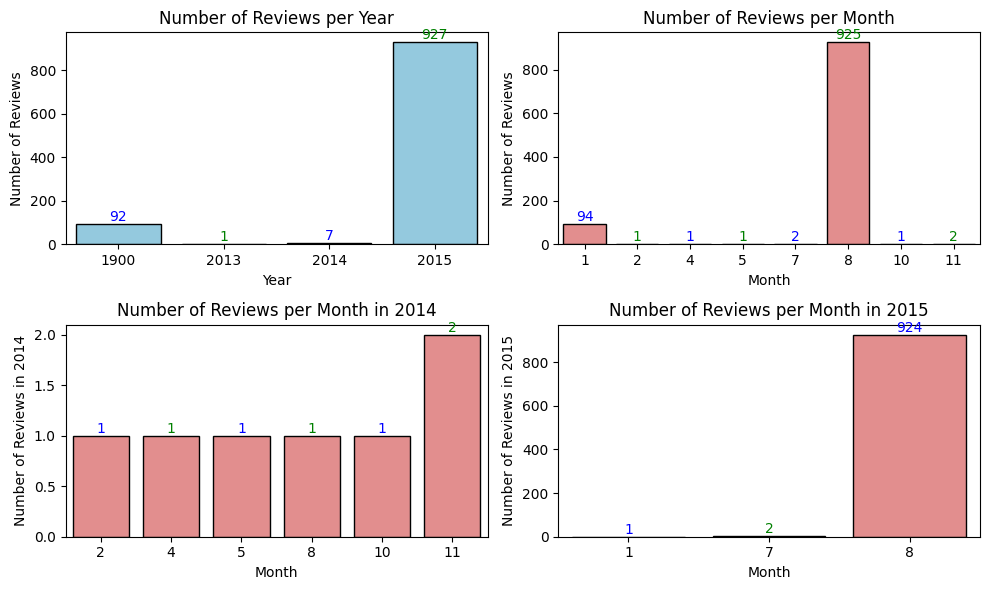

In [45]:

def format_bar_text(i, row):
    # format the row value with commas for thousands
    formatted_row = "{:,}".format(row)
    # alternately color the text for better visibility
    if i % 2 == 0:        
        return formatted_row, 'blue'
    else:
        return formatted_row, 'green'

def set_bar_text(plt, x_values):
    for i, (index, row) in enumerate(x_values.items()):
        formatted_row, color = format_bar_text(i, row)
        plt.text(i, row, formatted_row, ha='center', va='bottom', color=color)

plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1)
sns.barplot(x=df["review_year"].value_counts().sort_index().index, y=df["review_year"].value_counts().sort_index().values, color='skyblue', edgecolor='black')
# show the count of reviews on top of each bar
set_bar_text(plt, df["review_year"].value_counts().sort_index())

plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.title("Number of Reviews per Year")

plt.subplot(2, 2, 2)
sns.barplot(x=df["review_month"].value_counts().sort_index().index, y=df["review_month"].value_counts().sort_index().values, color='lightcoral', edgecolor='black')
# show the count of reviews on top of each bar
set_bar_text(plt, df["review_month"].value_counts().sort_index())

plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.title("Number of Reviews per Month")

plt.subplot(2, 2, 3)
# filter where reivew_year = 2014
sns.barplot(x=df["review_month_2014"].value_counts().sort_index().index.astype(int), y=df["review_month_2014"].value_counts().sort_index().values, color='lightcoral', edgecolor='black')
# show the count of reviews on top of each bar
set_bar_text(plt, df["review_month_2014"].value_counts().sort_index())

plt.xlabel("Month")
plt.ylabel("Number of Reviews in 2014")
plt.title("Number of Reviews per Month in 2014")

plt.subplot(2, 2, 4)
# filter where reivew_year = 2015
sns.barplot(x=df["review_month_2015"].value_counts().sort_index().index.astype(int), y=df["review_month_2015"].value_counts().sort_index().values, color='lightcoral', edgecolor='black')
# show the count of reviews on top of each bar
set_bar_text(plt, df["review_month_2015"].value_counts().sort_index())

plt.xlabel("Month")
plt.ylabel("Number of Reviews in 2015")
plt.title("Number of Reviews per Month in 2015")

plt.tight_layout()
plt.show()



In [46]:
url_re = re.compile(r"https?://\S+|www\.\S+")
html_re = re.compile(r"<.*?>")

def clean_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = s.lower().strip()
    s = url_re.sub(" ", s)
    s = html_re.sub(" ", s)
    s = re.sub(r"[^a-z0-9\s\.,!?\'\"\-]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["review_body_clean"] = df["review_body"].apply(clean_text)

2. Exploratory Data Analysis (EDA) with Pandas & visualization libraries
    - Compute summary statistics for ratings and helpful votes
    - Create correlation matrices to analyze relationships between star_rating, helpful_votes, and verified_purchase
    - Identify the most and least reviewed products using grouping and aggregation
    - Visualize the distribution of ratings across product categories using Matplotlib and Seaborn

In [47]:
# compute summary statistics for ratings and helpful votes
print("Summary Statistics for Star Ratings and helpful votes:")
print(df[["star_rating", "helpful_votes"]].describe())


Summary Statistics for Star Ratings and helpful votes:
       star_rating  helpful_votes
count  1027.000000    1027.000000
mean      4.326193       1.422590
std       1.209822       7.272783
min       1.000000       0.000000
25%       4.000000       0.000000
50%       5.000000       0.000000
75%       5.000000       1.000000
max       5.000000     148.000000


In [48]:
# Create correlation matrices to analyze relationships between star_rating, helpful_votes, and verified_purchase
df["verified_purchase"] = df["verified_purchase"].map({"Y": 1, "N": 0})

corr_matrix = df[["star_rating", "helpful_votes", "verified_purchase"]].corr()
print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
                   star_rating  helpful_votes  verified_purchase
star_rating           1.000000       0.037157          -0.174122
helpful_votes         0.037157       1.000000           0.023673
verified_purchase    -0.174122       0.023673           1.000000


In [49]:
# Identify the most and least reviewed products using grouping and aggregation
product_review_counts = df.groupby("product_title").size().sort_values(ascending=False)
most_reviewed_product = product_review_counts.idxmax()
least_reviewed_product = product_review_counts.idxmin()
print(f"Most Reviewed Product Title: {most_reviewed_product} with {product_review_counts.max()} reviews")
print(f"Least Reviewed Product Title: {least_reviewed_product} with {product_review_counts.min()} reviews")

product_review_counts = df.groupby("product_id").size().sort_values(ascending=False)
most_reviewed_product = product_review_counts.idxmax()
least_reviewed_product = product_review_counts.idxmin()
print(f"\nMost Reviewed Product ID: {most_reviewed_product} with {product_review_counts.max()} reviews")
print(f"Least Reviewed Product ID: {least_reviewed_product} with {product_review_counts.min()} reviews")

Most Reviewed Product Title: Clover Men's Aluminum Wallet with 41 reviews
Least Reviewed Product Title: Zonars Women's Backless Long Sleeve Blouse Top Large, Grey with 1 reviews

Most Reviewed Product ID: B013CSAW68 with 18 reviews
Least Reviewed Product ID: B013DPM7B8 with 1 reviews


C:\Users\15012\AppData\Local\Temp\ipykernel_17312\3718029845.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="star_rating", data=df, palette="viridis", edgecolor='black')


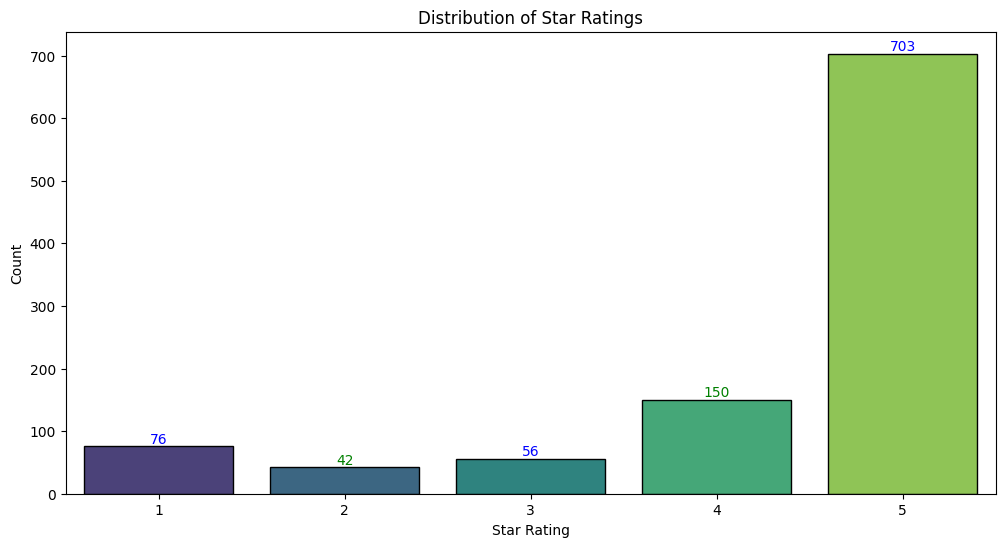

In [50]:
# Visualize the distribution of ratings across product categories using Matplotlib and Seaborn
plt.figure(figsize=(12, 6))
sns.countplot(x="star_rating", data=df, palette="viridis", edgecolor='black')
set_bar_text(plt, df["star_rating"].value_counts().sort_index())

plt.xlabel("Star Rating")
plt.ylabel("Count")
plt.title("Distribution of Star Ratings")
plt.show()

3. Statistical analysis & probability
    - Calculate measures of central tendency and dispersion for star_rating
    - Perform hypothesis testing to assess whether verified purchases result in more positive reviews
    - Apply Bayesian probability to predict the likelihood of a review being helpful based on historical data

In [51]:
# central tendency for star_rating
mean_rating = df["star_rating"].mean()
median_rating = df["star_rating"].median()
mode_rating = df["star_rating"].mode()[0]

# and dispersion for star_rating
range_rating = df["star_rating"].max() - df["star_rating"].min()
variance_rating = df["star_rating"].var()
std_rating = df["star_rating"].std()

print("Central Tendency for Star Ratings:")
print(f"Mean: {mean_rating:.2f}, Median: {median_rating}, Mode: {mode_rating}")
print("Dispersion for Star Ratings:")
print(f"Range: {range_rating}, Variance: {variance_rating:.2f}, Standard Deviation: {std_rating:.2f}")


Central Tendency for Star Ratings:
Mean: 4.33, Median: 5.0, Mode: 5
Dispersion for Star Ratings:
Range: 4, Variance: 1.46, Standard Deviation: 1.21


In [52]:
# Perform hypothesis testing to assess whether verified purchases result in more positive reviews
verified_reviews = df[df["verified_purchase"] == 1]["star_rating"]
unverified_reviews = df[df["verified_purchase"] == 0]["star_rating"]
t_stat, p_value = ttest_ind(verified_reviews, unverified_reviews, equal_var=False)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject the null hypothesis: Verified purchases have a statistically significant impact on star ratings.")
else:
    print("Fail to reject the null hypothesis: No statistically significant impact of verified purchases on star ratings.")



T-statistic: -5.4192, P-value: 0.0000
Reject the null hypothesis: Verified purchases have a statistically significant impact on star ratings.


In [53]:
# Apply Bayesian probability to predict the likelihood of a review being helpful based on historical data
# Check this block for validity

# Create a binary target variable for helpful reviews (e.g., helpful_votes > 0)
df["helpful_review"] = (df["helpful_votes"] > 0).astype(int)

# Use review_body_clean as the feature and helpful_review as the target

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["review_body_clean"])
y = df["helpful_review"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Classification Report for Naive Bayes Model:")
print(classification_report(y_test, y_pred))


Classification Report for Naive Bayes Model:
              precision    recall  f1-score   support

           0       0.65      0.89      0.75       131
           1       0.46      0.17      0.25        75

    accuracy                           0.63       206
   macro avg       0.56      0.53      0.50       206
weighted avg       0.58      0.63      0.57       206



4. Data visualization for business insights
    - Create bar charts to show the most popular product categories based on review counts
    - Use box plots to analyze the distribution of star_rating across categories
    - Develop heatmaps to visualize correlations between helpful_votes, total_votes, and verified_purchase
    - Plot time-series line charts to track changes in review patterns over the years

In [54]:
print(f"Total number of rows in the dataset: {df.shape[0]}, Total number of rows for Category Apparel: {df[df['product_category'] == 'Apparel'].shape[0]}")

Total number of rows in the dataset: 1027, Total number of rows for Category Apparel: 1027


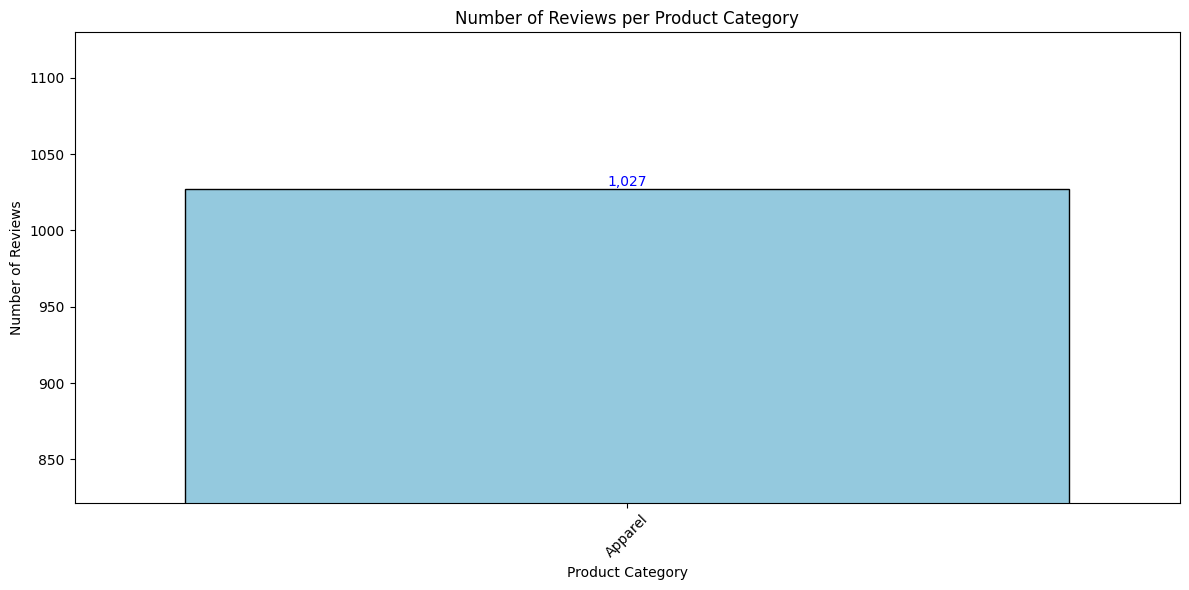

In [55]:
# Bar plot to show the most populat product categories based on the number of reviews
# As all the review are for Apparel category, the plot will show only one bar.
plt.figure(figsize=(12, 6))
sns.barplot(x=df["product_category"].value_counts().index, y=df["product_category"].value_counts().values, color='skyblue', edgecolor='black')
# show the count of reviews on top of each bar
set_bar_text(plt, df["product_category"].value_counts())

plt.xlabel("Product Category")
plt.ylabel("Number of Reviews")
plt.title("Number of Reviews per Product Category")
plt.xticks(rotation=45)
# use margin to show only top portion of the bar plot as there is only one category and the count is high.
apparel_count = df["product_category"].value_counts().values[0]
plt.ylim(apparel_count * 0.8, apparel_count * 1.1)
plt.tight_layout()
plt.show()

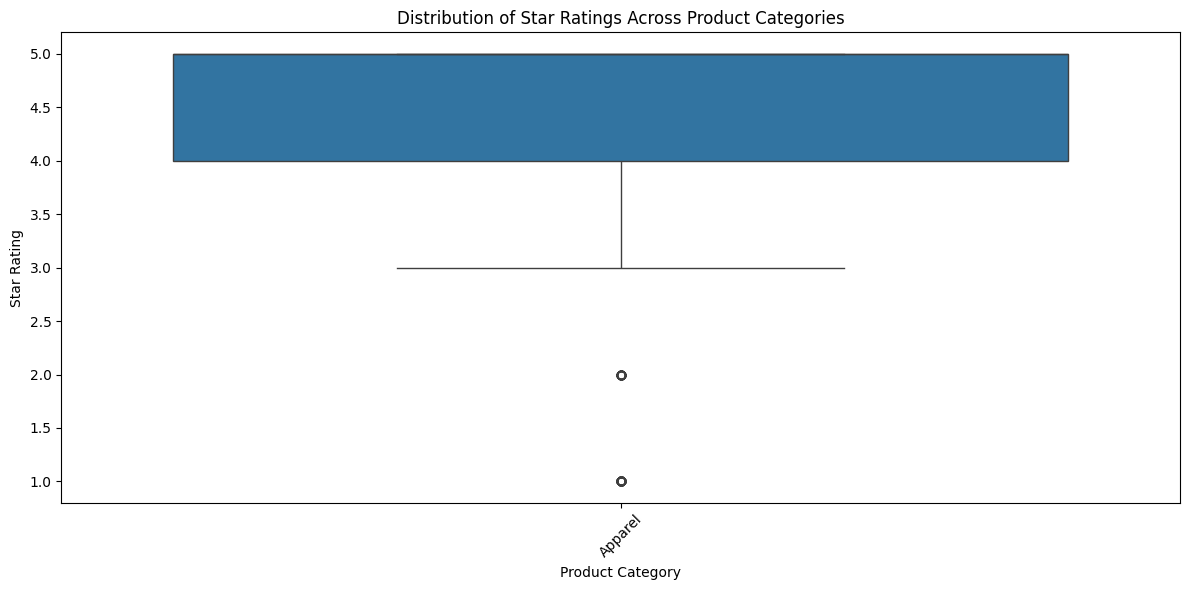

In [56]:
# Box plots to analyze the distribution of star_rating across categories
plt.figure(figsize=(12, 6))
sns.boxplot(x="product_category", y="star_rating", data=df)
plt.xlabel("Product Category")
plt.ylabel("Star Rating")
plt.title("Distribution of Star Ratings Across Product Categories")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

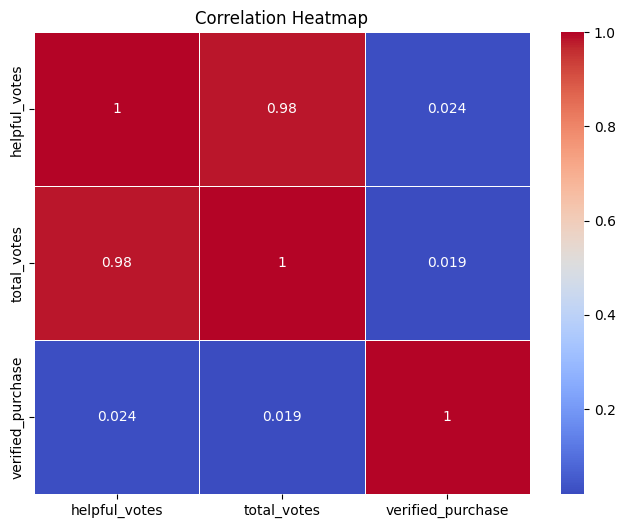

In [57]:
# heatmaps to visualize correlations between helpful_votes, total_votes, and verified_purchase
plt.figure(figsize=(8, 6))
sns.heatmap(df[["helpful_votes", "total_votes", "verified_purchase"]].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

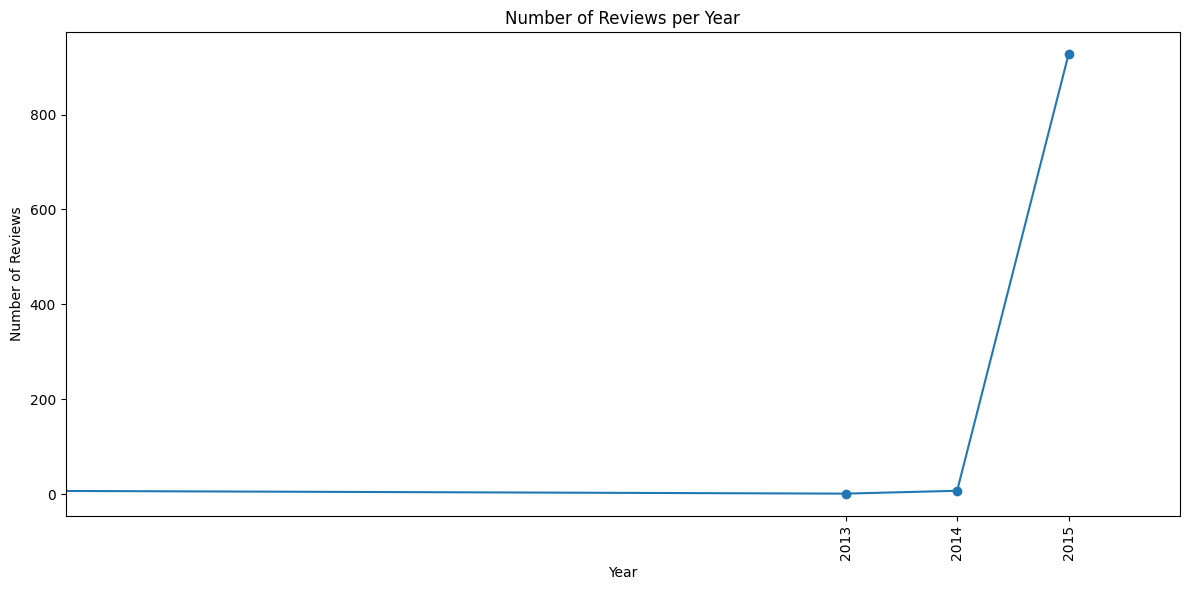

In [58]:
# Plot time-series line charts to track changes in review patterns over the years
plt.figure(figsize=(12, 6))
reviews_per_year = df.groupby("review_year").size()
reviews_per_year.plot(kind="line", marker="o")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.title("Number of Reviews per Year")
plt.xticks(reviews_per_year.index)
plt.xticks(rotation=90)
# As the dataset contains reviews from 2007 to 2015, we can set the x-axis limits to focus on this range.
plt.xlim(2006, 2016)
plt.tight_layout()
plt.show()


5. Feature engineering & data preparation for predictive analysis
    - Create a new feature, review_length, to analyze how review length impacts helpfulness
    - Convert categorical variables (verified_purchase, vine) into numerical formats
    - Apply one-hot encoding to categorical columns like product_category
    - Normalize numerical features such as total_votes and helpful_votes using scaling techniques

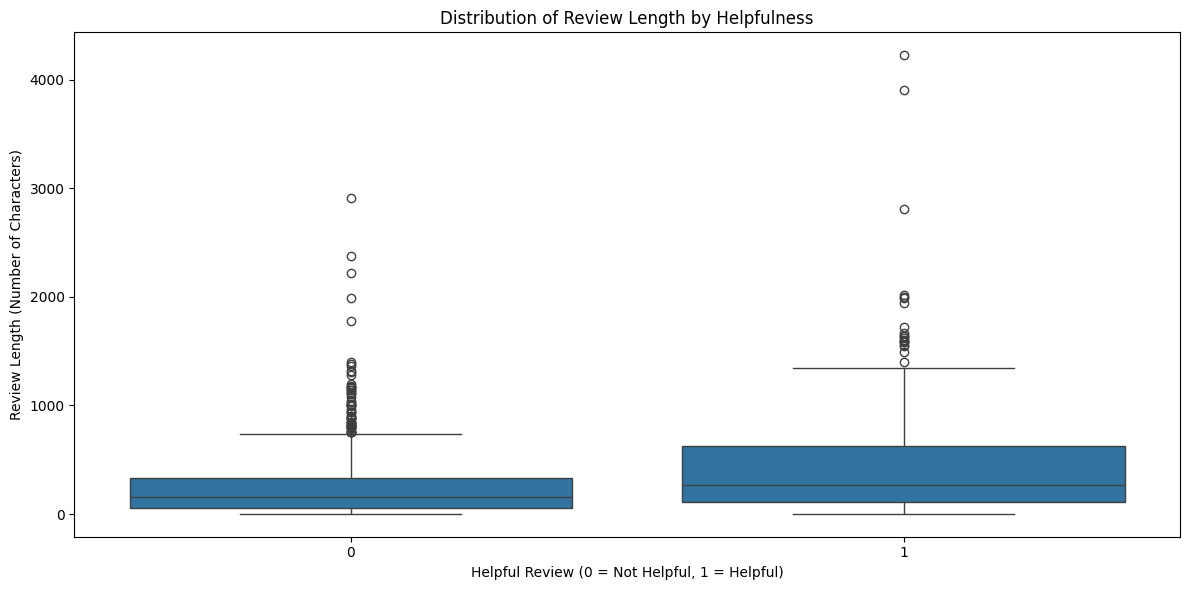

In [59]:
# review_length and the impact on helpfulness
df["review_length"] = df["review_body"].apply(lambda x: len(str(x)))
plt.figure(figsize=(12, 6))
sns.boxplot(x="helpful_review", y="review_length", data=df)
plt.xlabel("Helpful Review (0 = Not Helpful, 1 = Helpful)")
plt.ylabel("Review Length (Number of Characters)")
plt.title("Distribution of Review Length by Helpfulness")
plt.tight_layout()
plt.show()

In [60]:
# Convert categorical variables (verified_purchase, vine) into numerical formats
# Verfied purchase is already converted to numerical format in block 11. So skipping here.
#df["verified_purchase"] = df["verified_purchase"].map({"Y": 1, "N": 0})
df["vine"] = df["vine"].map({"Y": 1, "N": 0})

In [61]:
# Apply one-hot encoding to categorical columns like product_category
# As there is only one category, the one-hot encoding will not create any new columns and the original product_category is dropped. 
# So commenting out the one-hot encoding for product_category.
# df = pd.get_dummies(df, columns=["product_category"], drop_first=True)

In [62]:
# Normalize numerical features such as total_votes and helpful_votes using scaling techniques
numerical_columns = ['total_votes', 'helpful_votes']

scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

df.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,...,review_body,review_date,review_year,review_month,review_day,review_month_2014,review_month_2015,review_body_clean,helpful_review,review_length
0,US,32158956,R1KKOXHNI8MSXU,B01KL6O72Y,24485154,Easy Tool Stainless Steel Fruit Pineapple Core...,Apparel,4,-0.1957,-0.220786,...,"These Really Do Work Great, But You Do Need To...",2013-01-14,2013,1,14,NaN,NaN,"these really do work great, but you do need to...",0,2911
14,US,42025740,R1P11MVDZ65LMH,B019MDXIXG,387286513,Warner's Women's No Wedgies No Worries Modern ...,Apparel,5,-0.1957,-0.220786,...,Great fit.,2014-02-14,2014,2,14,2.0,NaN,great fit.,0,10
5,US,26631939,R1C4QH63NFL5NJ,B01FWRXN0Y,366144407,Levi's Boys' 514 Straight Fit Jeans,Apparel,5,-0.1957,-0.220786,...,Excellent for my 6 feet skinny 15 years old boy.,2014-04-22,2014,4,22,4.0,NaN,excellent for my 6 feet skinny 15 years old boy.,0,48
9,US,27477484,R2S79GCF6J89OA,B01DDULIJK,110598191,"Alexander Del Rossa Mens Satin Pajamas, Short ...",Apparel,3,-0.1957,-0.220786,...,"Shirt a bit too long, with heavy hem, which in...",2014-05-24,2014,5,24,5.0,NaN,"shirt a bit too long, with heavy hem, which in...",0,197
27,US,22116819,R3R04PVN99PTJX,B014MSSP66,494754914,SEOBEAN Mens Low Rise Sexy Sport Swimwear Trun...,Apparel,5,-0.1957,-0.220786,...,"Thank you very much, it's very beautiful",2014-08-22,2014,8,22,8.0,NaN,"thank you very much, it's very beautiful",0,40


#### Section 2: Machine learning models

1. Data preprocessing & feature engineering
    - Clean missing values in review_body, star_rating, and total_votes
    - Convert text data into numerical features using TF-IDF or word embeddings
    - Extract features like review length, sentiment polarity, and helpfulness score
    - Apply one-hot encoding to categorical variables such as verified_purchase

In [63]:
# Clean missing values was already done, so skipping here.
# Convert text data into numerical features using techniques like TF-IDF or word embeddings for modeling purposes.
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X_tfidf = vectorizer.fit_transform(df['review_body_clean'])
# Convert X_tfidf matrix to array and then to list
df['review_text_tfidf'] = X_tfidf.toarray().tolist()

# Extract features like review length, sentiment polarity, and helpfulness score
df['review_length'] = df['review_body_clean'].str.len()
df['sentiment_polarity'] = df['review_body_clean'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['helpfulness_score'] = df.apply(lambda row: row['helpful_votes'] / row['total_votes'] if row['total_votes'] !=0 else 0, axis=1)

df = pd.get_dummies(df, columns=['verified_purchase'], drop_first=True)

df.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,...,review_day,review_month_2014,review_month_2015,review_body_clean,helpful_review,review_length,review_text_tfidf,sentiment_polarity,helpfulness_score,verified_purchase_1
0,US,32158956,R1KKOXHNI8MSXU,B01KL6O72Y,24485154,Easy Tool Stainless Steel Fruit Pineapple Core...,Apparel,4,-0.1957,-0.220786,...,14,NaN,NaN,"these really do work great, but you do need to...",0,2814,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.130181,0.886379,True
14,US,42025740,R1P11MVDZ65LMH,B019MDXIXG,387286513,Warner's Women's No Wedgies No Worries Modern ...,Apparel,5,-0.1957,-0.220786,...,14,2.0,NaN,great fit.,0,10,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.600000,0.886379,True
5,US,26631939,R1C4QH63NFL5NJ,B01FWRXN0Y,366144407,Levi's Boys' 514 Straight Fit Jeans,Apparel,5,-0.1957,-0.220786,...,22,4.0,NaN,excellent for my 6 feet skinny 15 years old boy.,0,48,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.46336305...",0.550000,0.886379,True
9,US,27477484,R2S79GCF6J89OA,B01DDULIJK,110598191,"Alexander Del Rossa Mens Satin Pajamas, Short ...",Apparel,3,-0.1957,-0.220786,...,24,5.0,NaN,"shirt a bit too long, with heavy hem, which in...",0,195,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-0.010000,0.886379,True
27,US,22116819,R3R04PVN99PTJX,B014MSSP66,494754914,SEOBEAN Mens Low Rise Sexy Sport Swimwear Trun...,Apparel,5,-0.1957,-0.220786,...,22,8.0,NaN,"thank you very much, it's very beautiful",0,40,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1.000000,0.886379,True


2. Exploratory Data Analysis (EDA) & visualization
    - Analyze rating distributions across product categories
    - Visualize word frequency in reviews using word clouds
    - Plot helpful_votes against review_length to identify trends in review usefulness
    - Use heatmaps and pair plots to study feature correlations

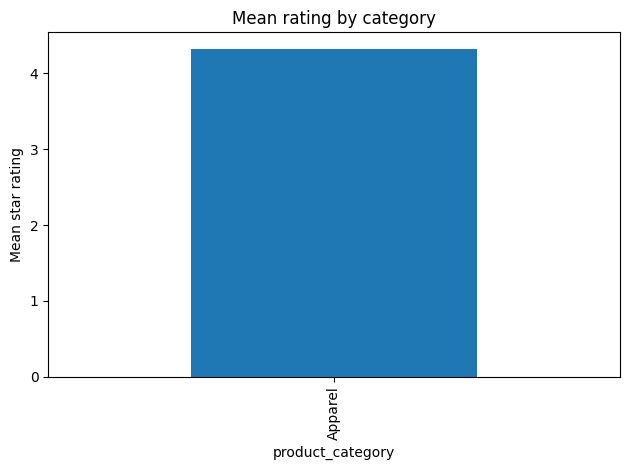

In [64]:
# Analyze rating distributions across product categories
ax = df.groupby('product_category')['star_rating'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Mean rating by category')
plt.ylabel('Mean star rating')
plt.tight_layout()
plt.show()

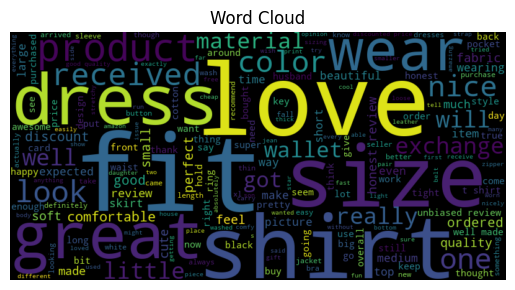

Use WordCloud or Tfidf vocabulary: ['really', 'work', 'great', 'need', 'know', 'things', 've', 'using', 'years', 'paid', 'price', 'try', 'extremely', 'careful', 'thing', 'cut', 'don', 'let', 'use', '34']


In [65]:
# Visualize word frequency in reviews using word clouds
text = df['review_body_clean'].fillna('')
wc = WordCloud(width=800, height=400).generate(' '.join(text.sample(min(20000, len(text))).values))
plt.imshow(wc, interpolation='bilinear'); 
plt.axis('off'); 
plt.title('Word Cloud'); 
plt.show()
print('Use WordCloud or Tfidf vocabulary:', list(vectorizer.vocabulary_)[:20])

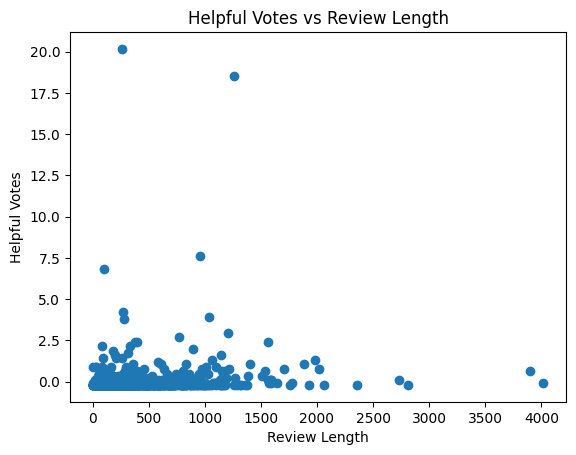

In [66]:
# Plot helpful_votes against review_length to identify trends in review usefulness
plt.scatter(df['review_length'], df['helpful_votes'])
plt.xlabel('Review Length')
plt.ylabel('Helpful Votes')
plt.title('Helpful Votes vs Review Length')
plt.show()

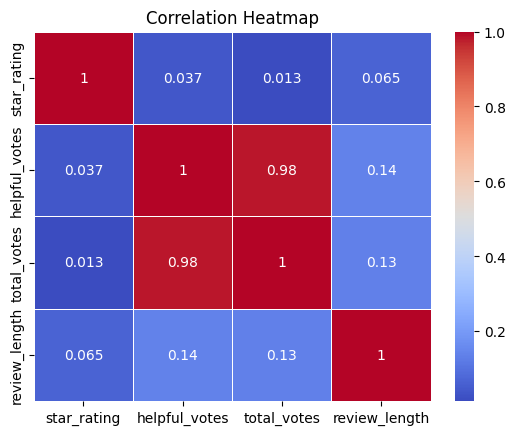

In [67]:
# Use heatmaps and pair plots to study feature correlations
sns.heatmap(df[['star_rating','helpful_votes','total_votes','review_length']].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

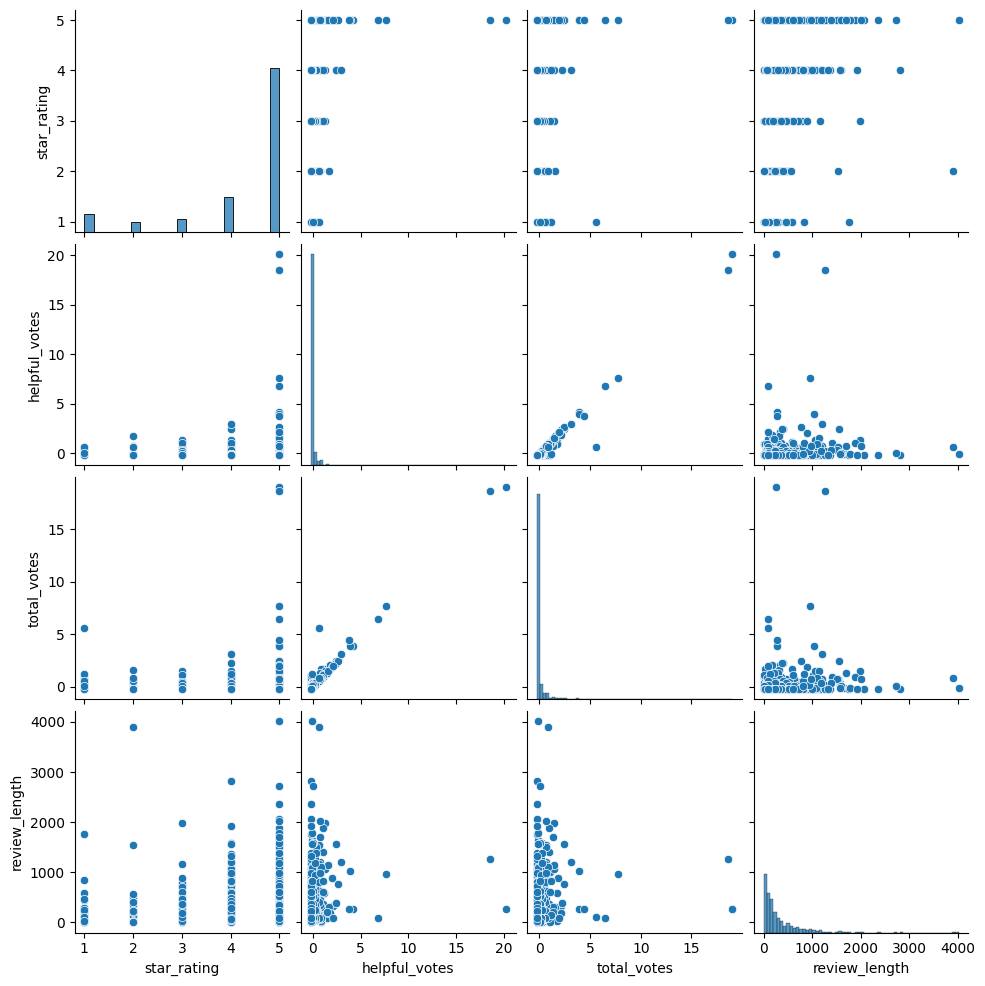

In [68]:
sns.pairplot(df[['star_rating','helpful_votes','total_votes','review_length']].fillna(0))
plt.show()

3. Supervised Learning: Regression models
    - Implement Linear Regression to predict star ratings
    - Apply Lasso and Ridge regression for feature selection and regularization
    - Evaluate models using R-squared, MSE, and RMSE metrics

In [69]:
df.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,...,review_day,review_month_2014,review_month_2015,review_body_clean,helpful_review,review_length,review_text_tfidf,sentiment_polarity,helpfulness_score,verified_purchase_1
0,US,32158956,R1KKOXHNI8MSXU,B01KL6O72Y,24485154,Easy Tool Stainless Steel Fruit Pineapple Core...,Apparel,4,-0.1957,-0.220786,...,14,NaN,NaN,"these really do work great, but you do need to...",0,2814,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.130181,0.886379,True
14,US,42025740,R1P11MVDZ65LMH,B019MDXIXG,387286513,Warner's Women's No Wedgies No Worries Modern ...,Apparel,5,-0.1957,-0.220786,...,14,2.0,NaN,great fit.,0,10,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.600000,0.886379,True
5,US,26631939,R1C4QH63NFL5NJ,B01FWRXN0Y,366144407,Levi's Boys' 514 Straight Fit Jeans,Apparel,5,-0.1957,-0.220786,...,22,4.0,NaN,excellent for my 6 feet skinny 15 years old boy.,0,48,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.46336305...",0.550000,0.886379,True
9,US,27477484,R2S79GCF6J89OA,B01DDULIJK,110598191,"Alexander Del Rossa Mens Satin Pajamas, Short ...",Apparel,3,-0.1957,-0.220786,...,24,5.0,NaN,"shirt a bit too long, with heavy hem, which in...",0,195,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-0.010000,0.886379,True
27,US,22116819,R3R04PVN99PTJX,B014MSSP66,494754914,SEOBEAN Mens Low Rise Sexy Sport Swimwear Trun...,Apparel,5,-0.1957,-0.220786,...,22,8.0,NaN,"thank you very much, it's very beautiful",0,40,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1.000000,0.886379,True


In [70]:
# Implement Linear Regression to predict star ratings
X = df[['review_length', 'sentiment_polarity']].fillna(0)
y = df['star_rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

models = {
    'LinearRegression': LinearRegression(),
    'Lasso': Lasso(alpha=0.001, max_iter=10000),
    'Ridge': Ridge(alpha=1.0)
}

for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    preds = mdl.predict(X_test)
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = mse**0.5
    print(f'{name}:\n\t R2={r2:.3f} | MSE={mse:.3f} | RMSE={rmse:.3f}')

LinearRegression:
	 R2=0.215 | MSE=1.145 | RMSE=1.070
Lasso:
	 R2=0.216 | MSE=1.144 | RMSE=1.070
Ridge:
	 R2=0.217 | MSE=1.142 | RMSE=1.069


4. Supervised Learning: Classification models
    - Build a Logistic Regression model to classify reviews as positive, neutral, or negative
    - Train Decision Trees and Random Forests for sentiment analysis
    - Use Naïve Bayes and K-Nearest Neighbors (KNN) for classification tasks
    - Evaluate models using accuracy, precision, recall, and F1-score

In [71]:
# Build a Logistic Regression model to classify reviews as positive, neutral, or negative
def classify_sentiment(polarity):
    if polarity > 0.1:
        return 'positive'
    elif polarity < -0.1:
        return 'negative'
    else:
        return 'neutral'

sentiment_classification = df['sentiment_polarity'].apply(classify_sentiment)
rating_classification = df['star_rating'].apply(lambda x: 'positive' if x >= 4 else ('negative' if x <= 2 else 'neutral'))

print("Sentiment Classification Distribution:")
print(sentiment_classification.value_counts())

print("\nRating Classification Distribution:")
print(rating_classification.value_counts())

cls_report = classification_report(sentiment_classification, rating_classification)

print("\nClassification Report for Sentiment vs Star Rating:")
print(cls_report)

Sentiment Classification Distribution:
sentiment_polarity
positive    845
neutral     148
negative     34
Name: count, dtype: int64

Rating Classification Distribution:
star_rating
positive    853
negative    118
neutral      56
Name: count, dtype: int64

Classification Report for Sentiment vs Star Rating:
              precision    recall  f1-score   support

    negative       0.22      0.76      0.34        34
     neutral       0.32      0.12      0.18       148
    positive       0.90      0.91      0.91       845

    accuracy                           0.79      1027
   macro avg       0.48      0.60      0.48      1027
weighted avg       0.80      0.79      0.78      1027



In [72]:
le = LabelEncoder()
y = le.fit_transform(sentiment_classification)  # pos/neu/neg -> 0/1/2 (order arbitrary)

print(text.shape)

X_text = vectorizer.fit_transform(text)
X_len = df['review_length'].fillna(0).values.reshape(-1, 1)
X_verified = df['verified_purchase_1'].map({'True': 1, 'False': 0}).fillna(0).astype(int).values.reshape(-1, 1)

X = hstack([X_text, X_len, X_verified])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

clfs = {
    'LogReg': LogisticRegression(max_iter=1000),
    'DecisionTree': DecisionTreeClassifier(max_depth=20, random_state=random_seed),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=random_seed),
    'NaiveBayes': MultinomialNB(),
    'KNN': KNeighborsClassifier(n_neighbors=7)
}

for name, clf in clfs.items():
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    print(f'\n{name}\n', classification_report(y_test, preds, target_names=le.classes_))
    print('Confusion matrix:\n', confusion_matrix(y_test, preds))

(1027,)


C:\Users\15012\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\15012\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\15012\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas


LogReg
               precision    recall  f1-score   support

    negative       0.00      0.00      0.00         9
     neutral       0.44      0.16      0.24        25
    positive       0.86      0.99      0.92       172

    accuracy                           0.84       206
   macro avg       0.44      0.38      0.39       206
weighted avg       0.77      0.84      0.80       206

Confusion matrix:
 [[  0   3   6]
 [  0   4  21]
 [  0   2 170]]

DecisionTree
               precision    recall  f1-score   support

    negative       1.00      0.22      0.36         9
     neutral       0.23      0.52      0.32        25
    positive       0.92      0.78      0.85       172

    accuracy                           0.73       206
   macro avg       0.72      0.51      0.51       206
weighted avg       0.84      0.73      0.76       206

Confusion matrix:
 [[  2   7   0]
 [  0  13  12]
 [  0  37 135]]

RandomForest
               precision    recall  f1-score   support

    negative  

C:\Users\15012\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\15012\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\15012\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

5. Handling imbalanced data in classification
    - Apply SMOTE (Synthetic Minority Over-sampling Technique) for balancing datasets
    - Use undersampling techniques to manage class imbalance
    - Experiment with class weighting to improve model performance

In [73]:
print(X_text.shape)
print(y.shape)

sm = SMOTE(random_state=random_seed)
X_small = X_text[:SUBSAMPLE_SIZE].toarray() if X_text.shape[0] > SUBSAMPLE_SIZE else X_text.toarray()
y_small = y[:X_small.shape[0]]
X_res, y_res = sm.fit_resample(X_small, y_small)
print('Original:', np.bincount(y_small), '| Resampled:', np.bincount(y_res))

# Class weights example with LogisticRegression
clf_w = LogisticRegression(max_iter=2000, class_weight='balanced')
clf_w.fit(X_train, y_train)
print('Weighted LogReg done.')

(1027, 1000)
(1027,)
Original: [ 34 148 845] | Resampled: [845 845 845]
Weighted LogReg done.


6. Ensemble Learning & model optimization
    - Implement Bagging with Random Forest for robust predictions
    - Apply Boosting techniques (AdaBoost, Gradient Boosting) to enhance accuracy
    - Combine models using Stacking for improved performance
    - Perform hyperparameter tuning with GridSearchCV

In [74]:
# Implement Bagging with Random Forest for robust predictions
base = LogisticRegression(max_iter=1000)
bag = BaggingClassifier(estimator=RandomForestClassifier(n_estimators=100, random_state=random_seed), n_estimators=10, random_state=random_seed)
boost = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=50, random_state=random_seed)
gboost = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=random_seed)
stack = StackingClassifier(estimators=[
    ('rf', RandomForestClassifier(n_estimators=100, random_state=random_seed)), 
    ('svc', LinearSVC(random_state=random_seed))
], final_estimator=LogisticRegression(), cv=5)

for name, mdl in [('Bagging', bag), ('AdaBoost', boost), ('GradientBoosting', gboost), ('Stacking', stack)]:
    mdl.fit(X_train, y_train)
    preds = mdl.predict(X_test)
    print(f'\n{name}:\n', classification_report(y_test, preds, target_names=le.classes_))

# Grid search example (on a small param space)
params = {'C':[0.1,1,10]}
gs = GridSearchCV(base, param_grid=params, cv=3, n_jobs=-1)
gs.fit(X_train, y_train)
print('Best params:', gs.best_params_, 'Best score:', gs.best_score_)



Bagging:
               precision    recall  f1-score   support

    negative       1.00      0.11      0.20         9
     neutral       0.45      0.20      0.28        25
    positive       0.87      0.98      0.92       172

    accuracy                           0.84       206
   macro avg       0.77      0.43      0.47       206
weighted avg       0.82      0.84      0.81       206



C:\Users\15012\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\15012\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\15012\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas


AdaBoost:
               precision    recall  f1-score   support

    negative       0.00      0.00      0.00         9
     neutral       0.00      0.00      0.00        25
    positive       0.83      1.00      0.91       172

    accuracy                           0.83       206
   macro avg       0.28      0.33      0.30       206
weighted avg       0.70      0.83      0.76       206


GradientBoosting:
               precision    recall  f1-score   support

    negative       0.75      0.33      0.46         9
     neutral       0.60      0.24      0.34        25
    positive       0.88      0.98      0.92       172

    accuracy                           0.86       206
   macro avg       0.74      0.52      0.58       206
weighted avg       0.84      0.86      0.83       206



C:\Users\15012\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\15012\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\15012\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\15012\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear 


Stacking:
               precision    recall  f1-score   support

    negative       0.00      0.00      0.00         9
     neutral       0.44      0.28      0.34        25
    positive       0.88      0.97      0.92       172

    accuracy                           0.84       206
   macro avg       0.44      0.42      0.42       206
weighted avg       0.79      0.84      0.81       206



Exception in thread ExecutorManagerThread:
Traceback (most recent call last):
  File "C:\Users\15012\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\psutil\_pswindows.py", line 666, in wrapper
    return fun(self, *args, **kwargs)
  File "C:\Users\15012\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\psutil\_pswindows.py", line 844, in kill
    return cext.proc_kill(self.pid)
           ~~~~~~~~~~~~~~^^^^^^^^^^
PermissionError: [WinError 5] Access is denied: '(originated from OpenProcess)'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3312.0_x64__qbz5n2kfra8p0\Lib\threading.py", line 1044, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\15012\AppData\Local\Packages\PythonSoftwareFo

BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

 
#### Section 3: Deep learning and advanced models

1. Neural Networks and Deep Neural Networks (DNNs)
    - Implement perceptron-based models for predicting product ratings
    - Use activation functions to optimize model performance
    - Apply forward propagation and backpropagation for neural network training
    - Optimize loss functions using Gradient Descent
    - Regularize DNNs with L1, L2 regularization, and dropout techniques

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_small, y_small, test_size=0.2, random_state=random_seed)

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(1)  # regression output
])

In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
es = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
hist = model.fit(X_train, y_train, validation_split=0.2, epochs=(2 * model_epochs), batch_size=256, callbacks=[es], verbose=1)
print('Evaluate:', model.evaluate(X_test, y_test, verbose=0))

Epoch 1/2
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 207ms/step - loss: 3.2542 - mae: 1.7386 - val_loss: 2.8899 - val_mae: 1.6531
Epoch 2/2
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 2.6041 - mae: 1.5527 - val_loss: 2.1846 - val_mae: 1.4346
Evaluate: [2.1784656047821045, 1.421790361404419]


2. Deep learning frameworks (TensorFlow, Keras, PyTorch)
    - Build DNN models using TensorFlow and Keras
    - Train and evaluate models with review text data
    - Compare PyTorch and TensorFlow implementations for efficiency
    - Apply batch normalization and early stopping to prevent overfitting

3. Convolutional Neural Networks (CNNs) for image classification
    - Preprocess image data for CNN-based tasks
    - Train CNN models to classify e-commerce product images
    - Implement ResNet for enhanced performance
    - Use image augmentation to improve model generalization

In [ ]:
if not os.path.exists(images_path):
    print(f"Directory '{images_path}' does not exist. Exiting...")
    # exit(1)  # Exit the program with an error code
else:
    print(f"Directory '{images_path}' exists. Proceeding to read the data...")
    image_count = len(list(pathlib.Path(images_path).glob('*.jpg')))
    print(f"Found {image_count} images in the directory.")

images_ds = keras.utils.image_dataset_from_directory(images_path, image_size=(224,224), batch_size=32)
NUM_CLASSES = len(images_ds.class_names)

images_ds = images_ds.cache().prefetch(tf.data.AUTOTUNE)


model_img = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(224,224,3)),
    layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Flatten(), layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
model_img.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_img.fit(images_ds, epochs=model_epochs)

Directory '../data/Images' exists. Proceeding to read the data...
Found 0 images in the directory.
Found 544 files belonging to 3 classes.
17/17 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.6158 - loss: 2.2910


In [ ]:
# Transfer learning
base = tf.keras.applications.EfficientNetB0(include_top=False, input_shape=(224,224,3), weights='imagenet')
base.trainable = False
tl = keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
tl.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
tl.fit(images_ds, epochs=model_epochs)

17/17 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.6654 - loss: 0.9267


4. Object detection with YOLO
    - Understand object detection techniques in e-commerce
    - Train YOLO models to detect multiple objects in product images
    - Prepare datasets and annotations for object detection tasks
    - Convert TensorFlow models to TensorFlow Lite for deployment

In [ ]:
yolo = YOLO('yolov10n.pt')  
yolo.train(data=data_file_path, epochs=image_epochs, imgsz=640)  # data.yaml describes train/val and class names

New https://pypi.org/project/ultralytics/8.4.19 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.234  Python-3.13.7 torch-2.9.1+cpu CPU (Intel Core i7-10510U 1.80GHz)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train6, nbs=64, nms=False, opset=None, optimize=False, 

c:\Users\15012\AppData\Local\Programs\Python\Python313\Lib\site-packages\ultralytics\utils\metrics.py:653: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
c:\Users\15012\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\15012\AppData\Local\Programs\Python\Python313\Lib\site-packages\ultralytics\utils\metrics.py:697: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
c:\Users\15012\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\15012\AppData\Local\Programs\Python\Python313\Lib\site-packages\ultralytics\utils\metrics.py:697: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
c:\Users\15012\AppData\Loca

                   all         98          0          0          0          0          0
WARNING no labels found in detect set, can not compute metrics without labels

1 epochs completed in 0.112 hours.
Optimizer stripped from C:\Mani\AIML\Python\03_Class_Work\FinalCapstone\Capstone1\src\runs\detect\train6\weights\last.pt, 5.7MB
Optimizer stripped from C:\Mani\AIML\Python\03_Class_Work\FinalCapstone\Capstone1\src\runs\detect\train6\weights\best.pt, 5.7MB

Validating C:\Mani\AIML\Python\03_Class_Work\FinalCapstone\Capstone1\src\runs\detect\train6\weights\best.pt...
Ultralytics 8.3.234  Python-3.13.7 torch-2.9.1+cpu CPU (Intel Core i7-10510U 1.80GHz)
YOLOv10n summary (fused): 102 layers, 2,265,558 parameters, 0 gradients, 6.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.2s/it 12.9s6.3ss


c:\Users\15012\AppData\Local\Programs\Python\Python313\Lib\site-packages\ultralytics\utils\metrics.py:653: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
c:\Users\15012\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\15012\AppData\Local\Programs\Python\Python313\Lib\site-packages\ultralytics\utils\metrics.py:697: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
c:\Users\15012\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\15012\AppData\Local\Programs\Python\Python313\Lib\site-packages\ultralytics\utils\metrics.py:697: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
c:\Users\15012\AppData\Loca

                   all         98          0          0          0          0          0
WARNING no labels found in detect set, can not compute metrics without labels
Speed: 2.6ms preprocess, 119.8ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to C:\Mani\AIML\Python\03_Class_Work\FinalCapstone\Capstone1\src\runs\detect\train6


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([], dtype=int64)
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001E537E36190>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
    

In [ ]:
 
# yolo.export(format='tflite')  # convert to TensorFlow Lite for deployment

Ultralytics 8.3.234  Python-3.13.7 torch-2.9.1+cpu CPU (Intel Core i7-10510U 1.80GHz)
YOLOv10n summary (fused): 102 layers, 2,265,558 parameters, 0 gradients, 6.5 GFLOPs

PyTorch: starting from 'C:\Mani\AIML\Python\03_Class_Work\FinalCapstone\Capstone1\src\runs\detect\train6\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.5 MB)
requirements: Ultralytics requirements ['tf_keras<=2.19.0', 'sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx2tf>=1.26.3'] not found, attempting AutoUpdate...
WARNING Retry 1/2 failed: Command 'pip install --no-cache-dir "tf_keras<=2.19.0" "sng4onnx>=1.0.1" "onnx_graphsurgeon>=0.3.26" "ai-edge-litert>=1.2.0" "onnx2tf>=1.26.3" --extra-index-url https://pypi.ngc.nvidia.com' returned non-zero exit status 1.
WARNING Retry 2/2 failed: Command 'pip install --no-cache-dir "tf_keras<=2.19.0" "sng4onnx>=1.0.1" "onnx_graphsurgeon>=0.3.26" "ai-edge-litert>=1.2.0" "onnx2tf>=1.26.3" --extra-index-url htt

ModuleNotFoundError: No module named 'onnx2tf'

5. Sequential modeling with RNNs and LSTMs
    - Implement RNNs for text classification
    - Train LSTM models to predict customer sentiments
    - Optimize performance using Gated Recurrent Units (GRUs)
    - Apply hybrid CRNN models for video-based product recommendations

In [ ]:
# Sequential Modeling with RNNs / LSTMs / GRUs

texts = df['review_body_clean'].astype(str).tolist()
labels = (df['star_rating'] >= 4).astype(int).values  # binary sentiment as example

tok = Tokenizer(num_words=max_words, oov_token='<UNK>')
tok.fit_on_texts(texts)
seqs = tok.texts_to_sequences(texts)
X_seq = pad_sequences(seqs, maxlen=max_len)

X_tr, X_te, y_tr, y_te = train_test_split(X_seq, labels, test_size=0.2, random_state=random_seed)

model_seq = keras.Sequential([
    layers.Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.GRU(64),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])
model_seq.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
es = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
model_seq.fit(X_tr, y_tr, validation_split=0.2, epochs=model_epochs, batch_size=256, callbacks=[es])
print('Evaluate:', model_seq.evaluate(X_te, y_te, verbose=0))

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6875 - loss: 0.6776 - val_accuracy: 0.8485 - val_loss: 0.6205
Evaluate: [0.6279394626617432, 0.8252426981925964]


6. Transfer learning for product categorization
    - Use pretrained models for transfer learning
    - Train models to classify product categories
    - Fine-tune CNN models to improve classification accuracy
    - Deploy transfer learning models in real-world applications

#### Section 4: Large Language Models (LLMs) and retrieval-based AI

1. Data preprocessing & retrieval setup
    - Load and preprocess datasets with product_title and related metadata
    - Implement fuzzy matching for retrieving relevant product details
    - Use vector databases (FAISS, Pinecone) to manage product embeddings

In [ ]:
# Minimal FAISS example with sentence-transformers
titles = df['review_headline'].fillna('').astype(str).tolist()  # or product_title if available
model = SentenceTransformer('all-MiniLM-L6-v2')
embs = model.encode(titles, convert_to_numpy=True, batch_size=64)

index = faiss.IndexFlatIP(embs.shape[1])  # cosine similarity via inner product with normalized vectors
# Normalize
norms = np.linalg.norm(embs, axis=1, keepdims=True)
embs_norm = embs / np.clip(norms, 1e-12, None)
index.add(embs_norm)
print('FAISS index size:', index.ntotal)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FAISS index size: 1027


In [ ]:
# Matching for product details
def fuzzy_lookup(query, choices, n=5, cutoff=0.6):
    return get_close_matches(query, choices, n=n, cutoff=cutoff)

# Example usage (replace with real product_title column)
choices = df['review_headline'].dropna().astype(str).unique().tolist()[:5000]
print(fuzzy_lookup('wireless earbuds', choices))

[]


2. Prompt engineering for LLM optimization
    - Design structured prompts to generate high-quality product descriptions
    - Apply temperature and top-k sampling to enhance response diversity

In [ ]:
# Example prompt template
prompt_template = """You are an e-commerce assistant. Given the product title and key specs, produce a concise, clear description.

Product Title: {title}
Key Features: {features}
Style: Informative, neutral, and helpful. Avoid fluff.
Length: 80-120 words.
"""

example = {'title': 'Noise-Cancelling Wireless Headphones', 'features': 'Bluetooth 5.3; 30h battery; USB-C fast charge'}
print(prompt_template.format(**example))

# Sampling knobs:
sampling = {'temperature': 0.7, 'top_k': 50, 'top_p': 0.95, 'max_new_tokens': 200}
print('Sampling params:', sampling)

You are an e-commerce assistant. Given the product title and key specs, produce a concise, clear description.

Product Title: Noise-Cancelling Wireless Headphones
Key Features: Bluetooth 5.3; 30h battery; USB-C fast charge
Style: Informative, neutral, and helpful. Avoid fluff.
Length: 80-120 words.

Sampling params: {'temperature': 0.7, 'top_k': 50, 'top_p': 0.95, 'max_new_tokens': 200}


3. Retrieval-Augmented Generation (RAG) implementation
    - Integrate retrieval-based search with LLM-generated content
    - Use LangChain or similar frameworks for RAG workflows
    - Fine-tune retrieval systems to improve result relevance

In [ ]:
# Use LangChain for RAG

from langchain_community.vectorstores import FAISS as LCFAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_classic.chains import RetrievalQA
from langchain_community.llms import HuggingFacePipeline

# Import necessary classes from transformers
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline as hf_pipeline

embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
vs = LCFAISS.from_texts(texts=titles, embedding=embeddings)
retriever = vs.as_retriever(search_kwargs={'k': 5})

# Manually load tokenizer and model for Flan-T5
tokenizer = AutoTokenizer.from_pretrained('google/flan-t5-base')
model = AutoModelForSeq2SeqLM.from_pretrained('google/flan-t5-base')

# Create the Hugging Face pipeline with the loaded model and tokenizer
# Use 'text-generation' as a task for Seq2Seq models
hf_pipeline_obj = hf_pipeline(
    "text-generation", # Changed from 'text2text-generation' to 'text-generation'
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=50 # Added for generation length control
)

# Initialize LangChain's HuggingFacePipeline with the custom pipeline object
llm = HuggingFacePipeline(pipeline=hf_pipeline_obj)

qa = RetrievalQA.from_chain_type(llm=llm, retriever=retriever)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM

In [ ]:

query = 'Summarize what customers like about wireless headphones.'
print(qa.run(query))

Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer.

Quality product-Excellent Customer Service

Good quality and comfortable fit

Great customer service

and how good product is

Sharp looking, top quality and perfect for those needing easy management.

Question: Summarize what customers like about wireless headphones.
Helpful Answer:


4. LLM fine-tuning & model selection
    - Fine-tune open-source LLMs (e.g., Mistral, LLaMA, Falcon) on product data
    - Adapt LLMs for e-commerce applications using transfer learning
    - Compare performance across models like GPT-4, LLaMA-2, etc

5. Application development & deployment
    - Build a simple web interface for user interaction
    - Enable product title input with AI-generated descriptions
    - Integrate real-time feedback for continuous model improvement

In [ ]:

def describe_product(title, features):
    # Call your LLM / prompt template here
    return f"Description for: {title}\nFeatures: {features}\n"
demo = gr.Interface(fn=describe_product,
                    inputs=[gr.Textbox(label='Product Title'), gr.Textbox(label='Key Features')],
                    outputs='text',
                    title='Product Description Generator')
demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [ ]:
# Summarization with transformers (if installed)
tokenizer_sum = AutoTokenizer.from_pretrained('sshleifer/distilbart-cnn-12-6')
model_sum = AutoModelForSeq2SeqLM.from_pretrained('sshleifer/distilbart-cnn-12-6')
sample_text = ' '.join(df['review_body_clean'].dropna().astype(str).head(20).tolist())

inputs = tokenizer_sum([sample_text], max_length=1024, return_tensors='pt', truncation=True)
summary_ids = model_sum.generate(inputs['input_ids'], num_beams=4, max_length=120, min_length=40, early_stopping=True)
summary_text = tokenizer_sum.decode(summary_ids[0], skip_special_tokens=True)
print(summary_text)

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


 i can't tell you how many times i went to wal-mart or the grocery store and their pineapples were just too small of a diameter . The bromelain in the pineapple keeps your gelatin from setting, but that same enzyme interferes with your jello setting up .


#### Detect spam/fake reviews by identifying unnatural language patterns

In [ ]:
# Simple rule-based model, you should adjust this
spam_rules = {
    'excessive_uppercase': df['review_body_clean'].str.count(r'[A-Z]').div(df['review_body_clean'].str.len().clip(lower=1)) > 0.5,
    'many_exclamations': df['review_body_clean'].str.count(r'!') > 5,
    'short_reviews': df['review_length'] < 3,
}
df['spam_flag'] = False
for k, mask in spam_rules.items():
    df['spam_flag'] |= mask.fillna(False)

# show first 5 rows with review_body_clean where spam_flag is True
df[df['spam_flag']][['review_body_clean','spam_flag']].head(5)


,review_body_clean,spam_flag
346,perfect fit!!! quality is good!!! and design i...,True
908,videoid 18e1633fb034b12fe8e76bc268ea3172 i am ...,True
964,videoid 4d63ef9d7eb00a74688e53ff9056a60c feel ...,True
922,this dress is made for a very short wasted per...,True
265,a,True
